In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import pytextrank
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel

/usr/local/lib/python3.12/dist-packages


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import zipfile
zip_path = '/content/drive/MyDrive/raw_analyst_ratings.csv.zip'  # change to your file name
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

In [ ]:
df=pd.read_csv('/content/data/raw_analyst_ratings.csv')
df

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A
...,...,...,...,...,...,...
1407323,1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX
1407324,1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX
1407325,1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX
1407326,1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX


In [ ]:
text_data = df['headline']
# Display descriptive statistics for the 'headline' column
print("Descriptive statistics for 'headline' column:")
print(df['headline'].describe())

# Check for missing values in the 'headline' column
print("\nMissing values in 'headline' column:")
print(df['headline'].isnull().sum())

# Count the number of articles per publisher
print(df.groupby("publisher")["headline"].value_counts())


Descriptive statistics for 'headline' column:
count                     1407328
unique                     845770
top       Benzinga's Top Upgrades
freq                         5449
Name: headline, dtype: object

Missing values in 'headline' column:
0
publisher    headline                                                                                   
47ertrends   Saturday, February 11, 2012 Stock Market Trends                                                9
             Saturday, February 18, 2012 Stock Market Trends                                                9
AARP         3 Ways Small Businesses Can Get Emergency Help Right Now                                       5
             5 Ways To Earn Money From Home As A Self-Employed Worker                                       2
ABNNewswire  Celamin Holdings NL (ASX:CNL) Update On Companies Projects And Activities                      3
                                                                                             

date
2009-02-14      1
2009-04-27      2
2009-04-29      1
2009-05-22      1
2009-05-27      6
             ... 
2020-05-30     14
2020-05-31     17
2020-06-01    205
2020-06-02    183
2020-06-03     69
Length: 3946, dtype: int64


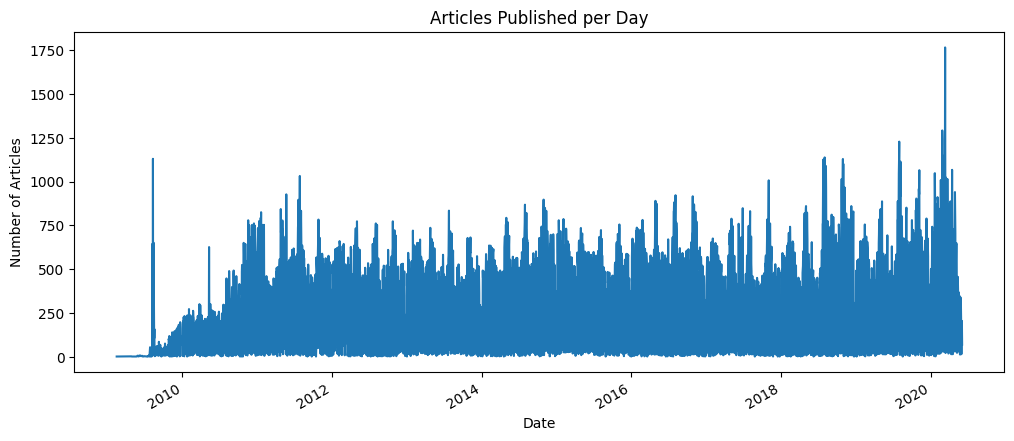

In [ ]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d %H:%M:%S", errors='coerce')
daily_counts = df.groupby('date').size()  # number of articles per day
print(daily_counts)
# Daily trend
daily_counts.plot(figsize=(12,5), title="Articles Published per Day")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()


## Text Analysis(Topic Modeling)

In [ ]:
# # Download necessary NLTK data
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

# load spcy's english model
nlp=spacy.load("en_core_web_sm")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# data processing
def text_processing(text):
  if isinstance(text,str):
    text=text.lower()
    text=text.translate(str.maketrans("","",string.punctuation))
    tokens=word_tokenize(text)
    stop_words=set(stopwords.words("english"))
    tokens=[word for word in tokens if word not in stop_words and len(word)>2]
    return tokens
  else:
    return []
# # Apply preprocessing to the 'headline' column
df["clean_headline"]=df["headline"].apply(text_processing)

In [ ]:
#  Create a dictionary from the processed headlines
dictionary=Dictionary(df["clean_headline"])

#  Create a corpus (a list of bag-of-words representations)
corpus=[dictionary.doc2bow(text) for text in df["clean_headline"]]

In [ ]:
# Train the LDA model
# You can adjust the number of topics (num_topics) as needed
lda_model=LdaModel(corpus,num_topics=5, id2word=dictionary, passes=15)

In [15]:
# save the LDA model
lda_model.save("lda_model.model")

In [19]:
lda_model.save("Lda_Text_analaysis_model.model")

from google.colab import files
files.download("Lda_Text_analaysis_model.model")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# Print the topics found by the LDA model
print("\nTopics found by LDA model:")
for idx, topic in lda_model.print_topics(-1):
    print(f'Topic {idx}: {topic}')



Topics found by LDA model:
Topic 0: 0.043*"update" + 0.025*"market" + 0.019*"shares" + 0.010*"zynga" + 0.009*"yelp" + 0.009*"earnings" + 0.008*"yahoo" + 0.008*"markets" + 0.008*"western" + 0.007*"brands"
Topic 1: 0.032*"stocks" + 0.027*"utilities" + 0.026*"financials" + 0.017*"52week" + 0.014*"yum" + 0.013*"announces" + 0.011*"hit" + 0.011*"biotech" + 0.011*"highs" + 0.010*"ceo"
Topic 2: 0.052*"est" + 0.044*"eps" + 0.037*"sales" + 0.030*"reports" + 0.024*"buy" + 0.022*"raises" + 0.021*"target" + 0.021*"maintains" + 0.020*"price" + 0.018*"inc"
Topic 3: 0.020*"retail" + 0.020*"shares" + 0.017*"trading" + 0.016*"price" + 0.014*"staples" + 0.013*"tech" + 0.011*"sector" + 0.011*"says" + 0.010*"companies" + 0.010*"higher"
Topic 4: 0.037*"etfs" + 0.036*"stocks" + 0.025*"etf" + 0.024*"top" + 0.022*"benzingas" + 0.021*"benzinga" + 0.018*"energy" + 0.017*"sector" + 0.017*"pro" + 0.017*"check"


In [17]:
# Assign dominant topic to each headline
def get_dominant_topic(lda_model, bow):
    topics = lda_model.get_document_topics(bow)
    topics.sort(key=lambda x: x[1], reverse=True)
    if topics:
        return topics[0][0]
    return None

df['dominant_topic'] = [get_dominant_topic(lda_model, doc) for doc in corpus]

In [ ]:
# add PyTextRank to the spaCy pipeline
import spacy
import pytextrank

nlp = spacy.load("en_core_web_sm")

# Add PyTextRank to the pipeline
nlp.add_pipe("textrank")

# 3️⃣ Extract key phrases
phrases_list = []
for text in df['headline'].astype(str):
    doc = nlp(text)
    phrases = [phrase.text for phrase in doc._.phrases[:5]]  # top 5 phrases
    phrases_list.append(phrases)

df['key_phrases'] = phrases_list
df.head()

# Time Series Analysis

In [ ]:
# Identify spikes
spikes = daily_counts[daily_counts > daily_counts.mean() + 2*daily_counts.std()]
print(spikes)


## Publisher Analysis

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


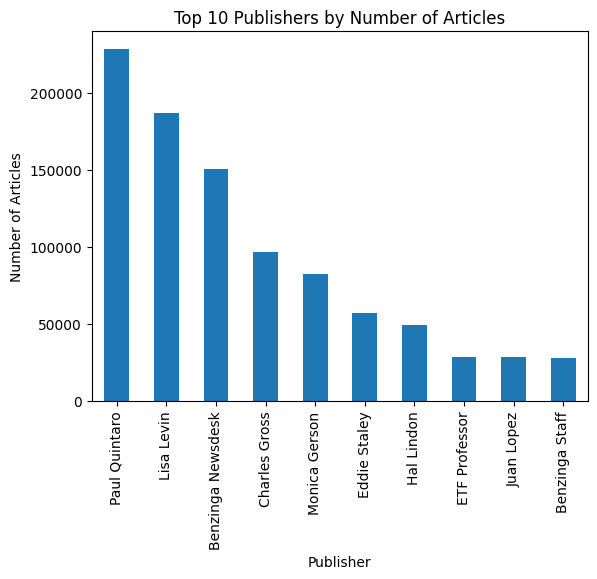

In [20]:
# Count articles per publisher
publisher_counts = df['publisher'].value_counts()
print(publisher_counts.head(10))  # Top 10 publishers

# Visualize publisher contribution
publisher_counts.head(10).plot(kind="bar")
plt.title("Top 10 Publishers by Number of Articles")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.show()